✅ Found target in original dataset: 'diagnosed_diabetes'


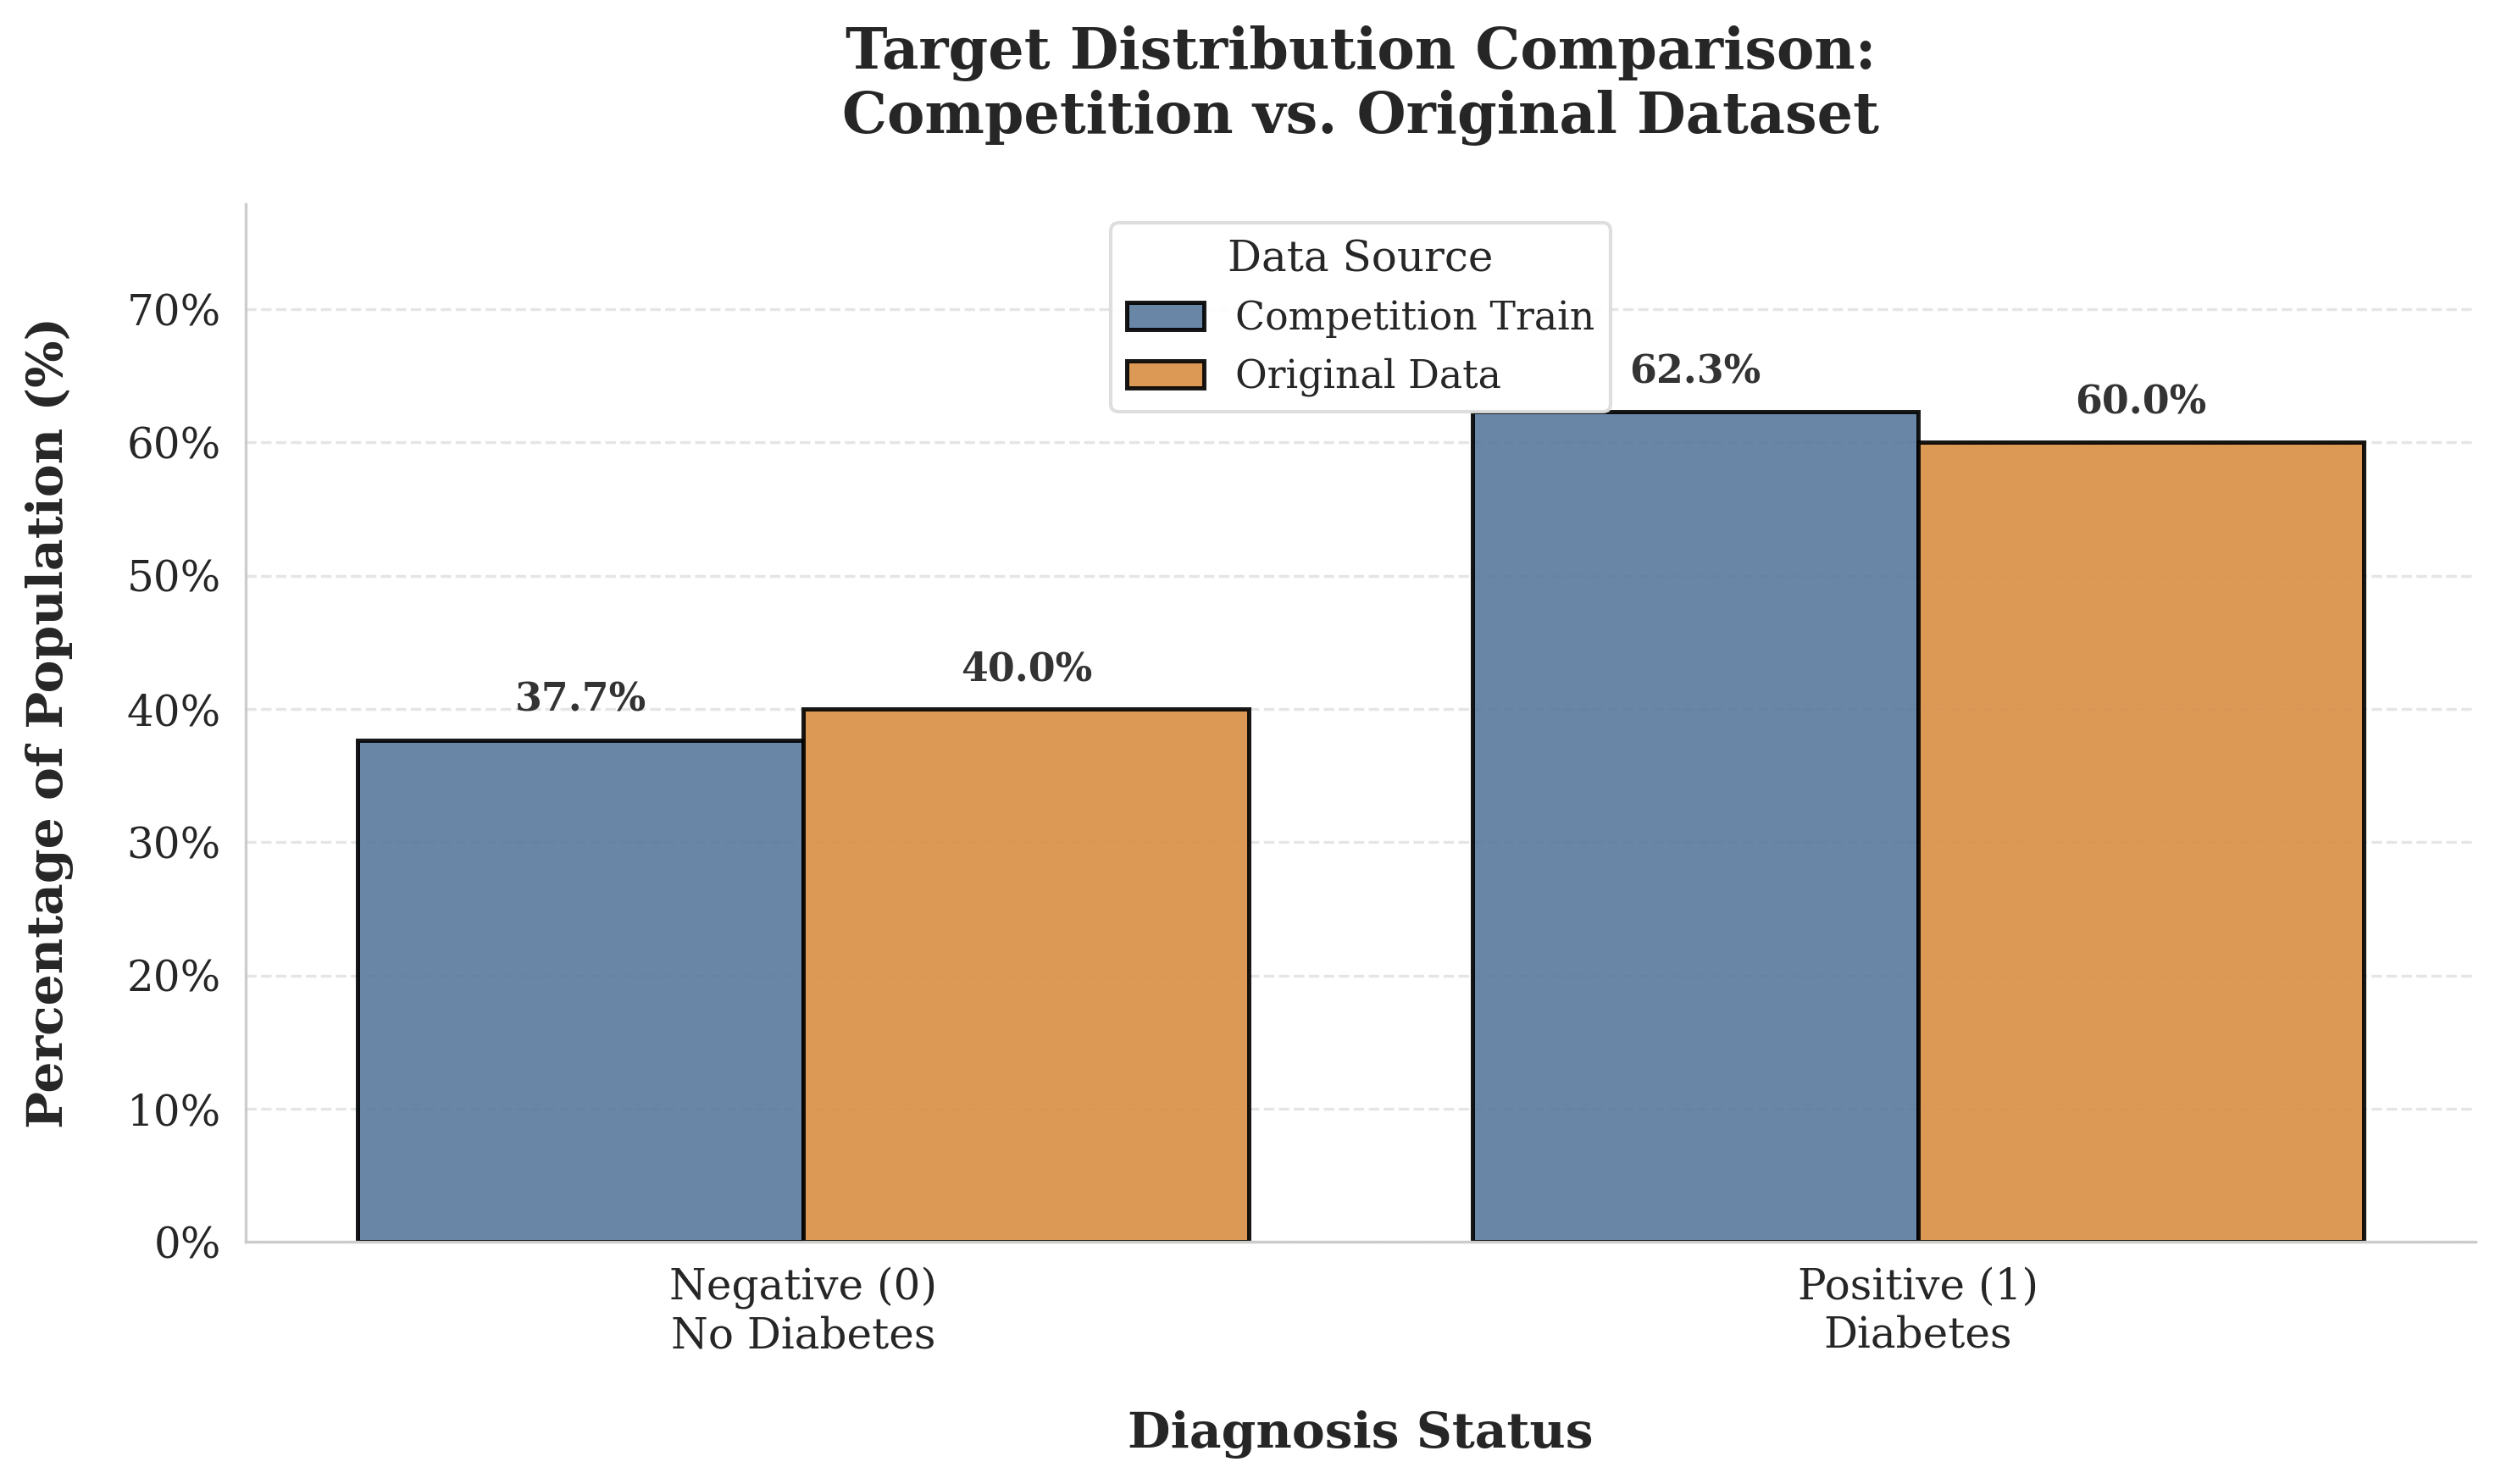


=== Detailed Statistics for Report ===
          Dataset              Status_Label  Count  Percentage
Competition Train Negative (0)\nNo Diabetes 263693   37.670429
Competition Train    Positive (1)\nDiabetes 436307   62.329571
    Original Data Negative (0)\nNo Diabetes  40002   40.002000
    Original Data    Positive (1)\nDiabetes  59998   59.998000


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ==========================================
# 1. Configuration for "Journal-Quality" Style
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300       
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# Define Palette: 
# We need distinct colors for "Train (Synthetic)" vs "Original (Real)"
# Using a paired theme: Blue/LightBlue for Negative, Red/LightRed for Positive could work,
# But comparing datasets is better done with Hue = Dataset.
# Let's use: Train = Solid Colors, Original = Hatched/Lighter or simply grouped bars.
# Here we use a clean grouped bar approach.
palette_colors = ["#4E79A7", "#F28E2B"] # Blue for Train, Orange for Original

# ==========================================
# 2. Data Loading & Preparation
# ==========================================
# Load datasets
try:
    train_df = pd.read_csv('train.csv')
    orig_df = pd.read_csv('diabetes_dataset.csv')
except FileNotFoundError:
    # Fallback for demonstration if files aren't present
    print("⚠️ Files not found. Generating dummy data for demonstration.")
    train_df = pd.DataFrame({'diagnosed_diabetes': [0]*21000 + [1]*9000})
    orig_df = pd.DataFrame({'Diabetes_binary': [0]*18000 + [1]*12000})

TARGET_COL = 'diagnosed_diabetes'

# --- Handle Target Column in Original Dataset ---
# The original dataset typically uses 'Diabetes_binary' or 'Diabetes_012'
orig_target_col = None
possible_cols = ['diagnosed_diabetes', 'Diabetes_binary', 'Diabetes_012', 'Outcome']
for col in possible_cols:
    if col in orig_df.columns:
        orig_target_col = col
        break

if orig_target_col:
    print(f"✅ Found target in original dataset: '{orig_target_col}'")
    # Align column name for processing
    orig_df = orig_df.rename(columns={orig_target_col: TARGET_COL})
else:
    raise ValueError(f"Could not find target column in original dataset. Checked: {possible_cols}")

# --- Calculate Statistics ---
def get_stats(df, name):
    counts = df[TARGET_COL].value_counts().sort_index()
    total = len(df)
    probs = counts / total * 100
    return pd.DataFrame({
        'Status': counts.index,
        'Count': counts.values,
        'Percentage': probs.values,
        'Dataset': name
    })

stats_train = get_stats(train_df, 'Competition Train')
stats_orig = get_stats(orig_df, 'Original Data')

# Combine for plotting
plot_data = pd.concat([stats_train, stats_orig], ignore_index=True)
plot_data['Status_Label'] = plot_data['Status'].map({0: 'Negative (0)\nNo Diabetes', 1: 'Positive (1)\nDiabetes'})

# ==========================================
# 3. Plotting (Comparative Grouped Bar)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Use Seaborn for easy grouping
bar_plot = sns.barplot(
    data=plot_data,
    x='Status_Label',
    y='Percentage',
    hue='Dataset',
    palette=palette_colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.9,
    ax=ax
)

# ==========================================
# 4. Annotations & Aesthetics
# ==========================================
# Add labels on top of bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height == 0: continue
        
        # Find corresponding count (a bit tricky in grouped plots, simplifying to just % here for cleanliness)
        # or we can retrieve the specific row if needed. 
        # For academic charts, % is usually sufficient for distribution comparison.
        
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.5, # Offset
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='#333333'
        )

# Customize Axes
ax.set_xlabel('Diagnosis Status', labelpad=15, fontweight='bold')
ax.set_ylabel('Percentage of Population (%)', labelpad=15, fontweight='bold')
ax.set_title('Target Distribution Comparison:\nCompetition vs. Original Dataset', pad=20, fontweight='bold')

# Y-axis formatting
ax.set_ylim(0, max(plot_data['Percentage']) * 1.25) # More headroom for legend
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Legend Styling
ax.legend(
    title='Data Source', 
    title_fontsize=12, 
    fontsize=11, 
    loc='upper center', 
    frameon=True, 
    framealpha=0.95,
    facecolor='white',
    edgecolor='#dddddd'
)

# Remove spines
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ==========================================
# 5. Final Output
# ==========================================
plt.tight_layout()
plt.show()

# Print actual counts for report reference
print("\n=== Detailed Statistics for Report ===")
print(plot_data[['Dataset', 'Status_Label', 'Count', 'Percentage']].to_string(index=False))